Comparing `leastsq` (standard) vs `least_squares` (new)
=======================================================

In [48]:
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import numpy as np
import thecannon as tc

In [49]:
# with open("labels_standard.pkl", "rb") as fileobj:
#     labels_standard, s2_standard, meta_standard = pickle.load(fileobj)

In [50]:
# with open("labels_new.pkl", "rb") as fileobj:
#     labels_new, s2_new, meta_new = pickle.load(fileobj)

In [51]:
# Read in the training labels and model spectra
# These are 1000 samples of labels 'EWT','LMA','N','CHL','CAR','ANT'
# used to modelled spectra at wavelengths 400..1..2500nm with the PROSPECT code
LUC_labels  = pd.read_csv('PROSPECT_input.csv')
LUC_spectra = pd.read_csv('PROSPECT_LUT.csv')

# Prepare input for a complete and restrictred Cannon model
prospect_wavelength = np.arange(400,2501,1)

labels = [
    'EWT',
    'LMA',
    'N',
    'CHL',
    'CAR',
    'ANT',
    ]
prospect_labels = np.array(LUC_labels[labels])

labels_limited = ['EWT','LMA']
prospect_labels_limited = np.array(LUC_labels[labels_limited])

prospect_spectra = np.array(LUC_spectra).T
prospect_spectra_ivar = (100./prospect_spectra)**2.0 # SNR 100

for label in labels:
    print(f"{label:4s}: {np.min(LUC_labels[label]):.6e}, {np.max(LUC_labels[label]):.6e}")

EWT : 1.877323e-05, 5.997715e-02
LMA : 1.524955e-04, 5.987707e-02
N   : 1.005078e+00, 3.998169e+00
CHL : 2.424509e-01, 9.997812e+01
CAR : 2.172984e-02, 2.495823e+01
ANT : 2.470764e-03, 1.997834e+00


In [52]:
vec = tc.vectorizer.PolynomialVectorizer(list(labels[:3]), 2)
vec.get_human_readable_label_vector()

'1 + EWT + LMA + N + EWT^2 + EWT*LMA + EWT*N + LMA^2 + LMA*N + N^2'

In [53]:
%pdb off
# Initialise and train the complete Cannon Model
prospect_model = tc.CannonModel(
    prospect_labels.astype(np.float64),
    prospect_spectra.astype(np.float64), prospect_spectra_ivar.astype(np.float64),
    vectorizer=tc.vectorizer.PolynomialVectorizer(list(labels), 2), dispersion=prospect_wavelength)
# print(prospect_model.regularization)
prospect_theta, prospect_s2, prospect_metadata = prospect_model.train(threads=1)

2025-10-28 13:18:50,438 [INFO] Training 6-label CannonModel with 1000 input spectra and 2101 pixels/spectrum


Automatic pdb calling has been turned OFF
[==                                                                                                  ]   3% (53/2101)                          

stty: stdin isn't a terminal


[===                                                                                                 ]   3% (69/2101)                          

2025-10-28 13:18:50,687 [WARNING] Optimization warning (l_bfgs_b): ABNORMAL: 


...

[============================================================================================        ]  92% (1937/2101)                          

2025-10-28 13:18:52,397 [WARNING] Optimization warning (l_bfgs_b): ABNORMAL: 


[=============================================================================================       ]  93% (1954/2101)                          

2025-10-28 13:18:52,421 [WARNING] Optimization warning (l_bfgs_b): ABNORMAL: 


[====================================================================================================] 100% (2s)                                 


In [54]:
# Test the label recovery of the same spectra
%pdb off
labels_standard, s2_standard, meta_standard = prospect_model.test(prospect_spectra, prospect_spectra_ivar, fit_func=tc.fitting.fit_spectrum_orig)

Automatic pdb calling has been turned OFF


stty: stdin isn't a terminal
2025-10-28 13:18:52,613 [INFO] Running test step on 1000 spectra


[====================================================================================================] 100% (10s)                               


In [55]:
# Test the label recovery of the same spectra
%pdb off
labels_new, s2_new, meta_new = prospect_model.test(prospect_spectra, prospect_spectra_ivar, fit_func=tc.fitting.fit_spectrum, op_kwds={"method": "lm", "gtol": 2.23e-16})

Automatic pdb calling has been turned OFF


stty: stdin isn't a terminal
2025-10-28 13:19:02,628 [INFO] Running test step on 1000 spectra


[====================================================================================================] 100% (8s)                                


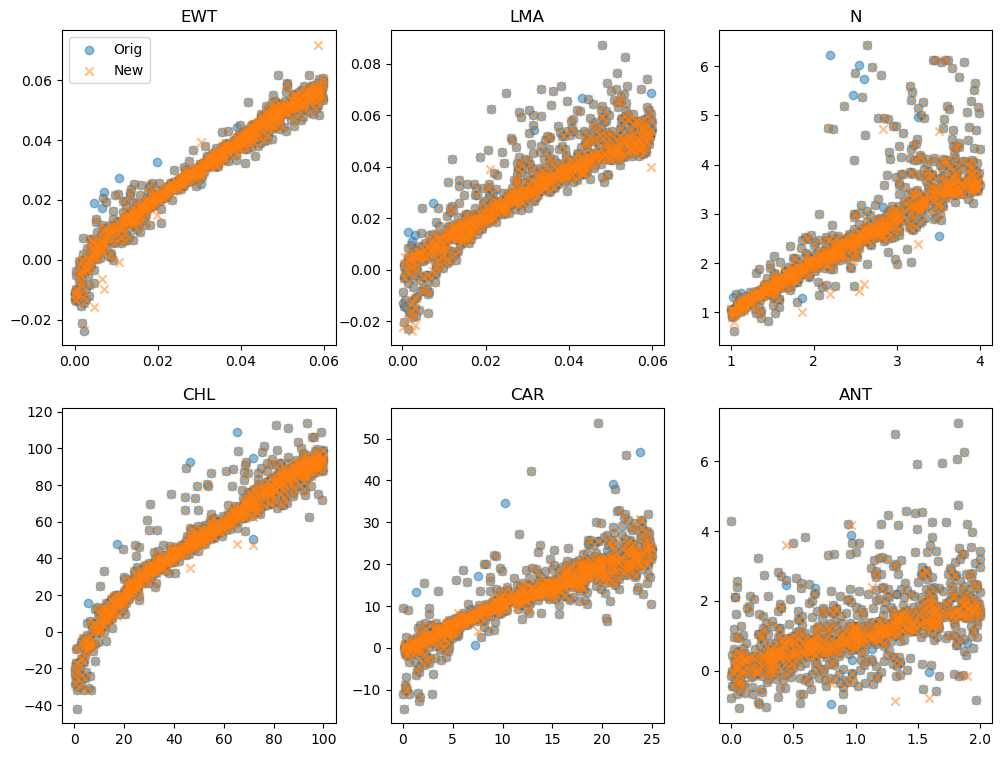

In [56]:
for i in range(len(labels)):
    fig = plt.gcf()
    ax = fig.add_subplot(2, int(np.ceil(len(labels)/2)), i+1)
    ax.scatter(prospect_labels[:,i], labels_standard[:,i], alpha=0.5, marker="o", label="Orig")
    ax.scatter(prospect_labels[:,i], labels_new[:,i], alpha=0.5, marker="x", label="New")
    ax.set_title(labels[i])
    if i == 0: ax.legend()
fig.set_size_inches((12, 9))

In [57]:
delta = np.abs(labels_standard - labels_new)

In [58]:
np.mean(delta), np.median(delta), np.std(delta)

(np.float64(0.0757521684593314),
 np.float64(1.8572637316971452e-09),
 np.float64(1.5694315255923275))

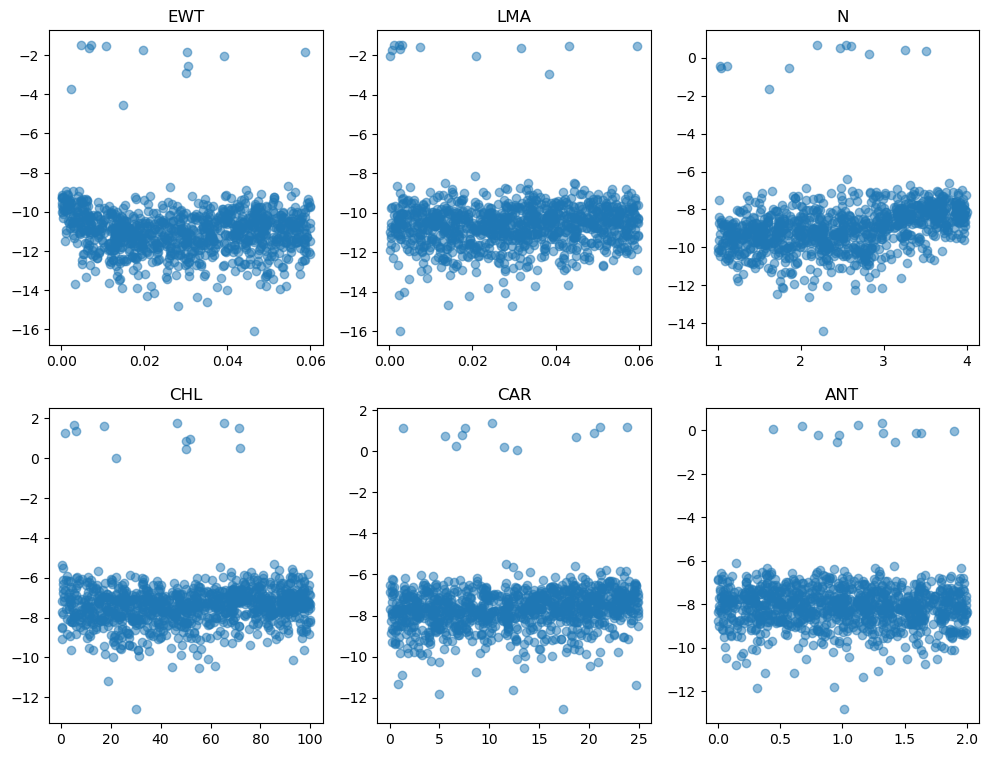

In [59]:
# Is there a correlation between fit mis-match and label value?
for i in range(len(labels)):
    fig = plt.gcf()
    ax = fig.add_subplot(2, int(np.ceil(len(labels)/2)), i+1)
    ax.scatter(prospect_labels[:,i], np.log10(delta[:,i]), alpha=0.5, marker="o")
    ax.set_title(labels[i])
fig.set_size_inches((12, 9))

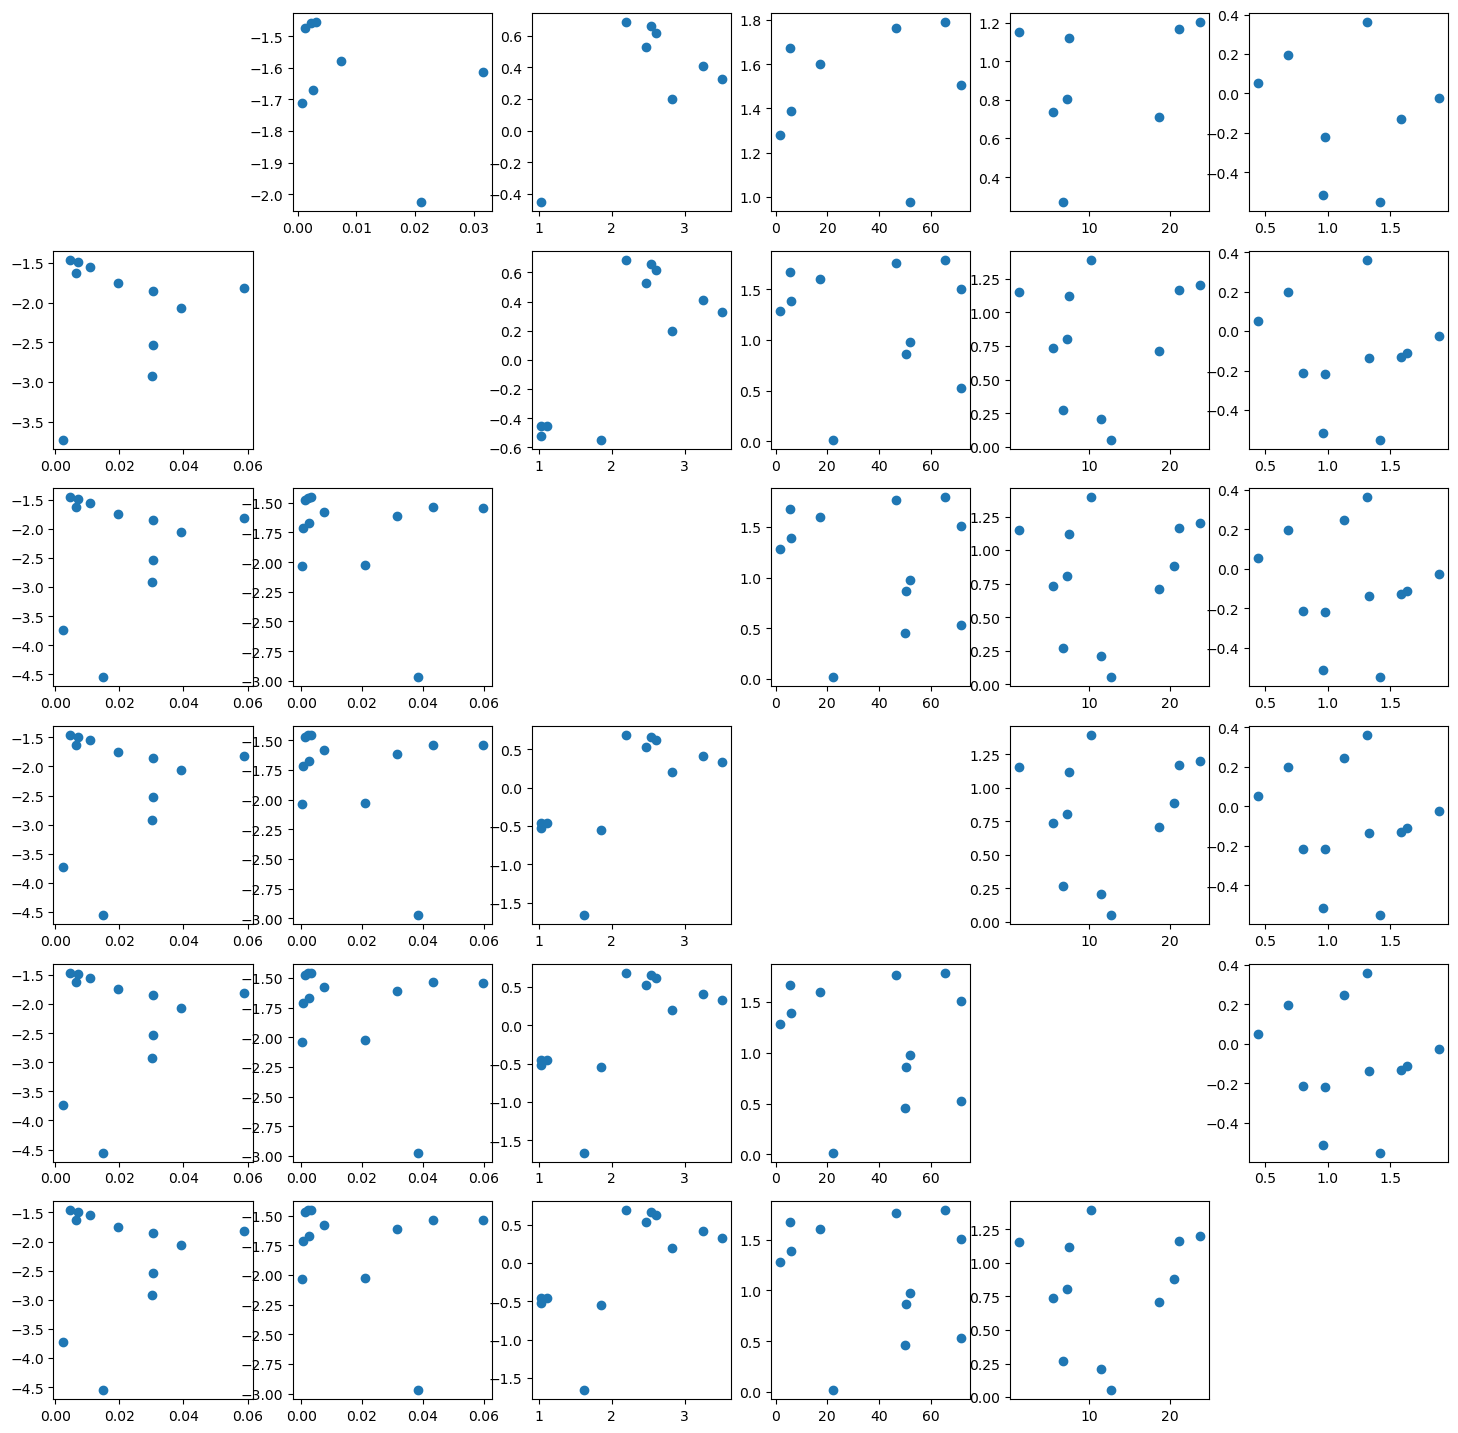

In [60]:
# Is there any correlation between where one label is an outlier, and another is? 
# i.e., do we get a totally different fit in a few pixels, or do we get a single outlying label for more pixels?

fig = plt.gcf()
for ref_ind in range(len(labels)):
    filt = np.log10(delta[:,ref_ind]) > -2.5
    for j in range(len(labels)):
        if j == ref_ind: continue
        ax = fig.add_subplot(len(labels), len(labels), ref_ind * len(labels) + j + 1)
        ax.scatter(prospect_labels[filt, j], np.log10(delta[filt, j]))
fig.set_size_inches((18, 18))

In [61]:
meta_standard[0].keys()

dict_keys(['fvec', 'nfev', 'njev', 'fjac', 'ipvt', 'qtf', 'x0', 'chi_sq', 'ier', 'mesg', 'model_flux', 'method', 'label_names', 'best_result_index', 'derivatives_used', 'snr', 'r_chi_sq', 'ftol', 'xtol', 'gtol', 'maxfev', 'factor', 'epsfcn'])

12


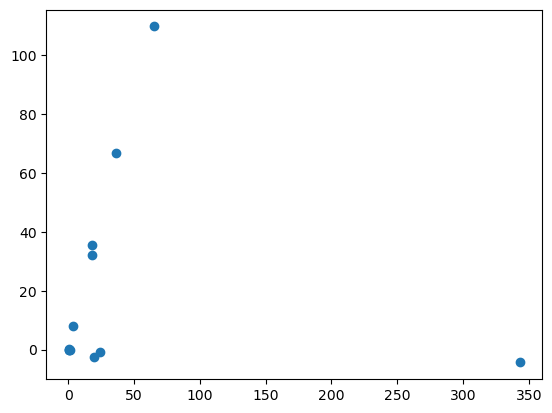

In [62]:
# What's the comparison of chi_sq in the standard and new regimes for these pixels with much different fit solutions?

chisq_standard = np.array([_["r_chi_sq"] for _ in meta_standard])
chisq_new = np.array([_["r_chi_sq"] for _ in meta_new])

filt = np.any(np.log10(delta) > -2.5, axis=1)
print(np.count_nonzero(filt))

scat = plt.scatter(chisq_standard[filt], chisq_new[filt] - chisq_standard[filt])

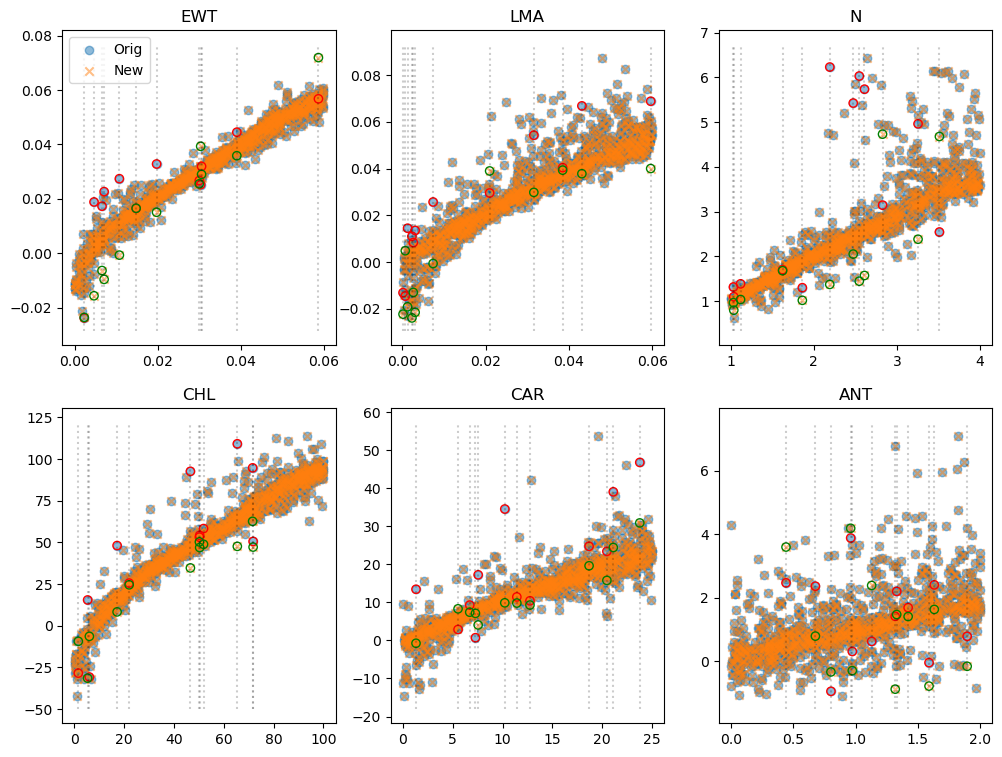

In [63]:
for i in range(len(labels)):
    fig = plt.gcf()
    ax = fig.add_subplot(2, int(np.ceil(len(labels)/2)), i+1)
    ax.scatter(prospect_labels[:,i], labels_standard[:,i], alpha=0.5, marker="o", label="Orig")
    ax.scatter(prospect_labels[:,i], labels_new[:,i], alpha=0.5, marker="x", label="New")
    ax.scatter(prospect_labels[filt, i], labels_standard[filt, i], alpha=1, marker="o", edgecolors="red", facecolors='none')
    ax.scatter(prospect_labels[filt, i], labels_new[filt, i], alpha=1, marker="o", edgecolors="green", facecolors='none')
    ax.vlines(prospect_labels[filt, i], *ax.get_ylim(), colors="k", linestyles="dotted", alpha=0.2)
    ax.set_title(labels[i])
    if i == 0: ax.legend()
fig.set_size_inches((12, 9))

In [64]:
np.array([_["mesg"] for _ in meta_new], dtype=str)[filt], np.array([_["mesg"] for _ in meta_standard], dtype=str)[filt]

(array(['`ftol` termination condition is satisfied.',
        '`xtol` termination condition is satisfied.',
        '`ftol` termination condition is satisfied.',
        '`xtol` termination condition is satisfied.',
        '`ftol` termination condition is satisfied.',
        '`ftol` termination condition is satisfied.',
        '`ftol` termination condition is satisfied.',
        '`ftol` termination condition is satisfied.',
        '`ftol` termination condition is satisfied.',
        '`ftol` termination condition is satisfied.',
        '`ftol` termination condition is satisfied.',
        '`xtol` termination condition is satisfied.'], dtype='<U60'),
 array(['The relative error between two consecutive iterates is at most 0.000000',
        'Both actual and predicted relative reductions in the sum of squares\n  are at most 0.000000',
        'Both actual and predicted relative reductions in the sum of squares\n  are at most 0.000000',
        'Both actual and predicted relative red

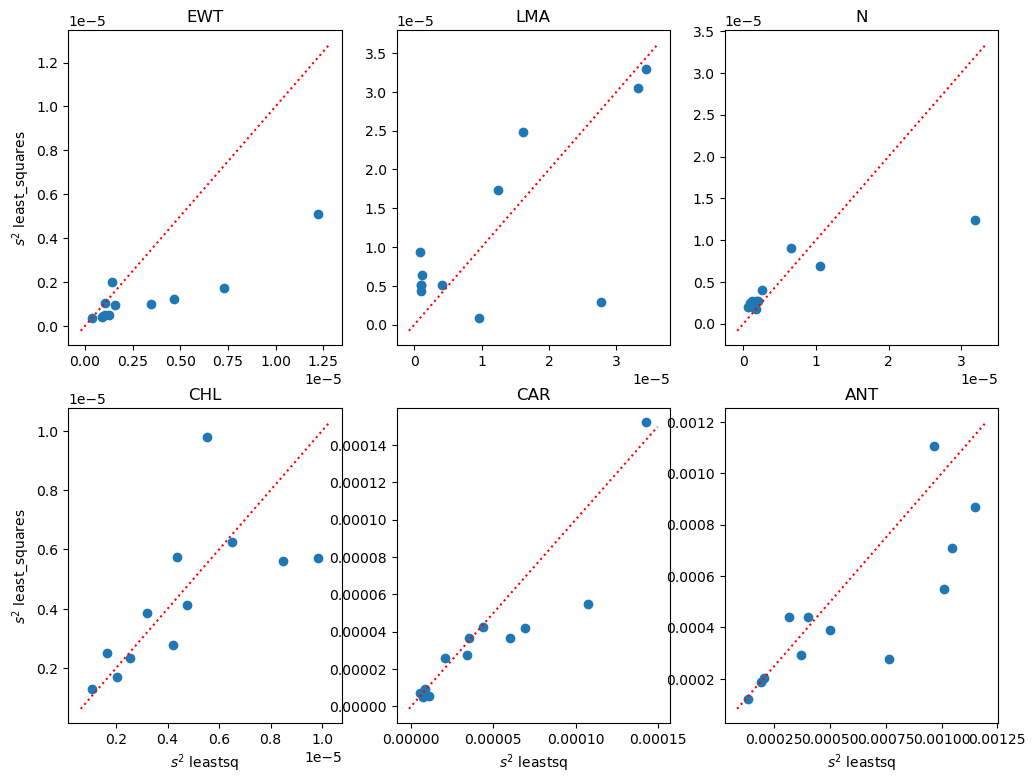

In [65]:
fig = plt.gcf()
for i in range(len(labels)):
    ax = fig.add_subplot(2, int(np.ceil(len(labels)/2)), i+1)
    ax.set_title(labels[i])
    ax.scatter(s2_standard[filt, i, i], s2_new[filt, i, i])
    # ax.set_xscale("log")
    # ax.set_yscale("log")
    if i % 3 == 0:
        ax.set_ylabel("$s^2$ least_squares")
    if i >= 3:
        ax.set_xlabel("$s^2$ leastsq")
    ax.plot(ax.get_xlim(), ax.get_xlim(), "r:")
fig.set_size_inches((12, 9))

Comparison between `least_squares` algorithms
---------------------------------------------

In [66]:
labels_lm, s2_lm, meta_lm = prospect_model.test(prospect_spectra, prospect_spectra_ivar, fit_func=tc.fitting.fit_spectrum, op_kwds={"method": "lm", "gtol": 2.23e-16})

stty: stdin isn't a terminal
2025-10-28 13:19:12,011 [INFO] Running test step on 1000 spectra


[====================================================================================================] 100% (8s)                                


In [67]:
labels_trf, s2_trf, meta_trf = prospect_model.test(prospect_spectra, prospect_spectra_ivar, fit_func=tc.fitting.fit_spectrum, op_kwds={"method": "trf", "gtol": 2.23e-16})

stty: stdin isn't a terminal
2025-10-28 13:19:19,594 [INFO] Running test step on 1000 spectra


[====================================================================================================] 100% (10s)                               


In [68]:
labels_dogbox, s2_dogbox, meta_dogbox = prospect_model.test(prospect_spectra, prospect_spectra_ivar, fit_func=tc.fitting.fit_spectrum, op_kwds={"method": "dogbox", "gtol": 2.23e-16})

stty: stdin isn't a terminal
2025-10-28 13:19:29,174 [INFO] Running test step on 1000 spectra


[====================================================================================================] 100% (9s)                                


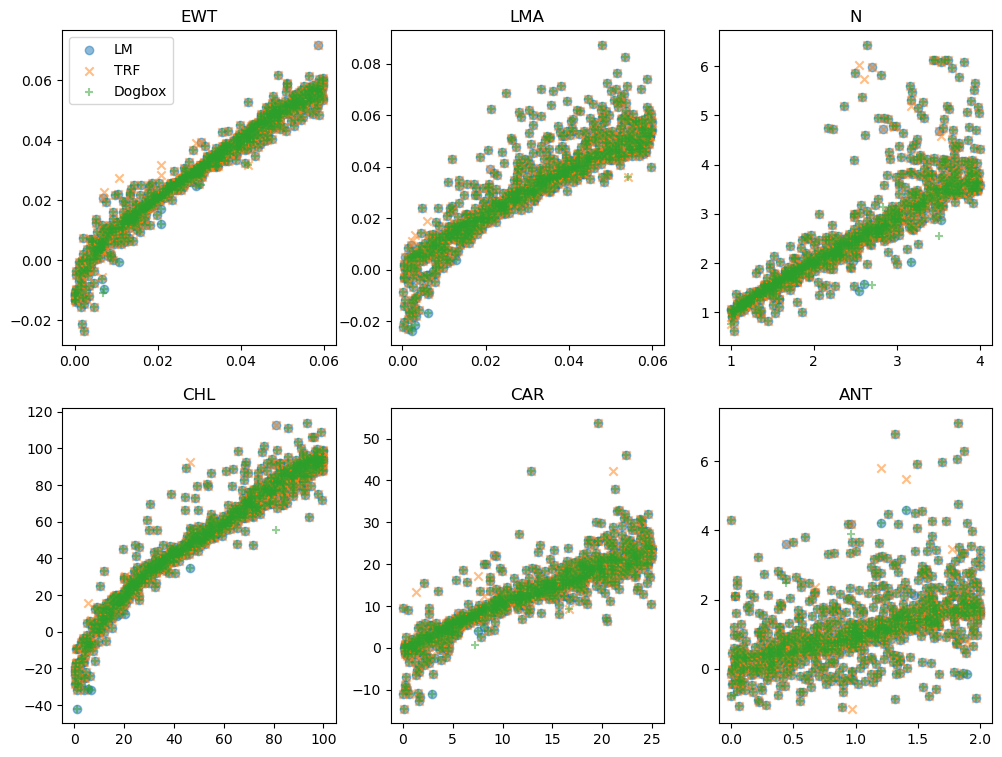

In [69]:
for i in range(len(labels)):
    fig = plt.gcf()
    ax = fig.add_subplot(2, int(np.ceil(len(labels)/2)), i+1)
    ax.scatter(prospect_labels[:,i], labels_lm[:,i], alpha=0.5, marker="o", label="LM")
    ax.scatter(prospect_labels[:,i], labels_trf[:,i], alpha=0.5, marker="x", label="TRF")
    ax.scatter(prospect_labels[:,i], labels_dogbox[:,i], alpha=0.5, marker="+", label="Dogbox")
    ax.set_title(labels[i])
    if i == 0: ax.legend()
fig.set_size_inches((12, 9))

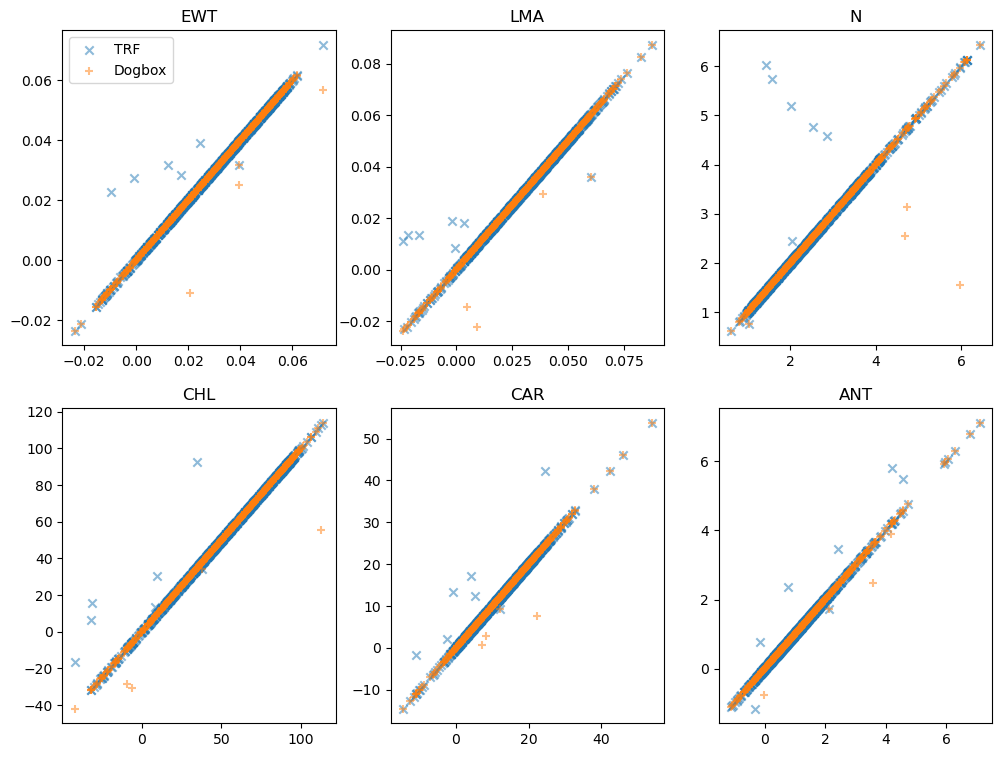

In [70]:
for i in range(len(labels)):
    fig = plt.gcf()
    ax = fig.add_subplot(2, int(np.ceil(len(labels)/2)), i+1)
    ax.scatter(labels_lm[:,i], labels_trf[:,i], alpha=0.5, marker="x", label="TRF")
    ax.scatter(labels_lm[:,i], labels_dogbox[:,i], alpha=0.5, marker="+", label="Dogbox")
    ax.set_title(labels[i])
    if i == 0: ax.legend()
fig.set_size_inches((12, 9))